In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df_clean = df.copy()
# jangan pernah cleaning data langsung ke data asli

In [4]:
# missing value
missing = (
    df_clean.isnull()
            .sum()
            .reset_index()
)

missing.columns = ["Column","Missing Value"]

missing["Percentage"] = (
    missing["Missing Value"]/len(df_clean)
)*100

missing.sort_values(
    by="Percentage",
    ascending=False
)

,Column,Missing Value,Percentage
7,loan_int_rate,3116,9.563856
3,person_emp_length,895,2.747000
1,person_income,0,0.000000
0,person_age,0,0.000000
2,person_home_ownership,0,0.000000
4,loan_intent,0,0.000000
5,loan_grade,0,0.000000
6,loan_amnt,0,0.000000
8,loan_status,0,0.000000
9,loan_percent_income,0,0.000000


Terdapat missing value pada beberapa kolom, Persentase missing akan dievaluasi untuk menentukan apakah data perlu dihapus atau dilakukan imputasi

In [5]:
# Penanganan Missing Value
# 1. person_emp_length
median_emp = df_clean["person_emp_length"].median()

df_clean["person_emp_length"] = (
    df_clean["person_emp_length"]
    .fillna(median_emp)
)

In [6]:
# 2. loan_int_rate
median_rate = df_clean["loan_int_rate"].median()

df_clean["loan_int_rate"] = (
    df_clean["loan_int_rate"]
    .fillna(median_rate)
)

In [7]:
df_clean.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [8]:
# cek duplicated
duplicates = df_clean.duplicated().sum()
duplicates

np.int64(165)

In [9]:
df_clean = df_clean.drop_duplicates()

In [10]:
df_clean.duplicated().sum()

np.int64(0)

In [11]:
# cek tipe data
df_clean.dtypes

person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

In [12]:
# cek nilai kategorikal
categorical_columns = df_clean.select_dtypes(include="object").columns

for col in categorical_columns:
    print("="*50)
    print(col)
    print(df_clean[col].value_counts())

person_home_ownership
person_home_ownership
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: int64
loan_intent
loan_intent
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64
loan_grade
loan_grade
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: int64
cb_person_default_on_file
cb_person_default_on_file
N    26686
Y     5730
Name: count, dtype: int64


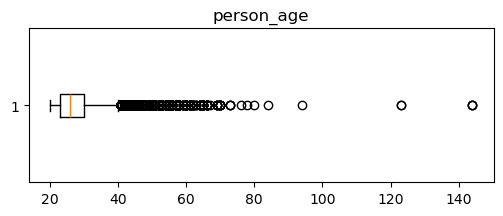

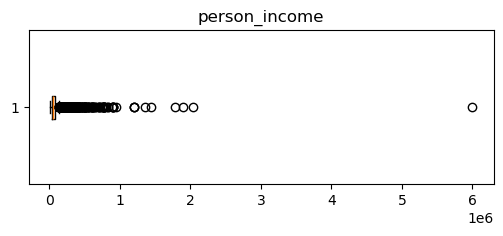

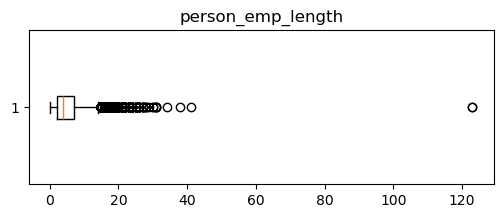

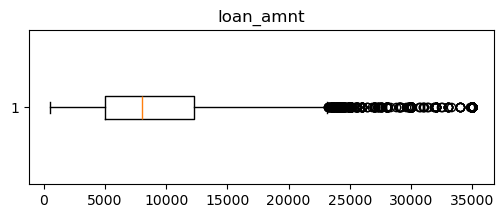

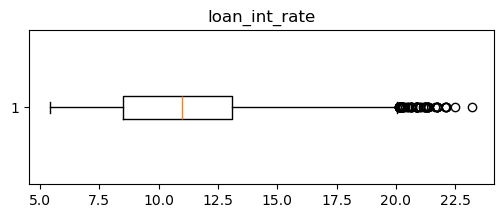

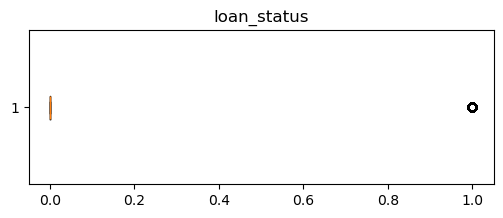

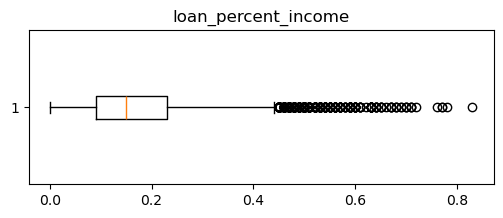

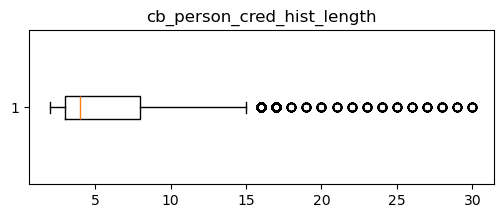

In [13]:
# cek outlier
import matplotlib.pyplot as plt

numeric_cols = df_clean.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(6,2))
    plt.boxplot(df_clean[col], vert=False)
    plt.title(col)
    plt.show()

In [14]:
# person age dengan umur lebih dari 100 hilangkan, karena tidak masuk akal 
df_clean = df_clean[df_clean["person_age"] <= 100]
df_clean["person_age"].describe()

count    32411.000000
mean        27.730369
std          6.210448
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max         94.000000
Name: person_age, dtype: float64

In [15]:
df_clean.sort_values(
    by="person_age",
    ascending=False
).head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32416,94,24000,RENT,1.0,MEDICAL,C,6500,10.99,0,0.27,N,27
32506,84,94800,MORTGAGE,2.0,PERSONAL,A,10000,7.51,0,0.11,N,24
32422,80,64000,RENT,7.0,MEDICAL,B,6800,11.71,0,0.11,N,25
32355,78,48000,RENT,41.0,MEDICAL,A,3000,7.51,0,0.06,N,25
32534,76,75000,RENT,23.0,MEDICAL,A,15000,8.94,0,0.20,N,25
32521,73,39240,RENT,0.0,MEDICAL,B,1800,12.53,0,0.05,N,21
32381,73,42000,MORTGAGE,7.0,PERSONAL,A,5000,7.49,0,0.12,N,28
32432,73,75000,RENT,0.0,MEDICAL,A,7800,10.99,0,0.10,N,24
32360,70,39996,RENT,4.0,MEDICAL,C,3600,15.23,0,0.09,Y,19
32522,70,48000,RENT,0.0,MEDICAL,A,15000,6.99,1,0.31,N,24


In [16]:
df_clean.sort_values(
    by="person_income",
    ascending=False
).head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
30049,42,2039784,RENT,0.0,VENTURE,C,8450,12.29,0,0.00,Y,15
32546,60,1900000,MORTGAGE,5.0,PERSONAL,A,1500,10.99,0,0.00,N,21
32497,63,1782000,RENT,13.0,EDUCATION,C,12025,14.27,0,0.01,N,30
31924,44,1440000,MORTGAGE,7.0,DEBTCONSOLIDATION,A,6400,7.40,0,0.00,N,15
31922,47,1362000,MORTGAGE,9.0,VENTURE,A,6600,7.74,0,0.00,N,17


In [17]:
# cek outlier person emp length
df_clean = df_clean[df_clean["person_emp_length"] <= 100]
df_clean.sort_values(
    by="person_emp_length",
    ascending=False
).head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32355,78,48000,RENT,41.0,MEDICAL,A,3000,7.51,0,0.06,N,25
32515,53,106000,MORTGAGE,38.0,PERSONAL,B,20000,9.88,0,0.19,N,23
32428,58,49000,MORTGAGE,34.0,MEDICAL,D,7500,13.55,1,0.15,Y,24
30914,48,70000,MORTGAGE,31.0,HOMEIMPROVEMENT,D,9000,14.54,0,0.13,N,17
32263,46,180000,MORTGAGE,31.0,MEDICAL,B,18000,9.91,0,0.10,N,12


In [18]:
df_clean.to_csv("cleaned_risk_dataset.csv", index=False)

# Data Cleaning Summary

## Missing Values
- Missing values pada `person_emp_length` diisi menggunakan median.
- Missing values pada `loan_int_rate` diisi menggunakan median.

## Duplicate Data
- Data duplikat diperiksa dan dihapus.

## Data Type
- Semua tipe data telah diverifikasi dan sesuai.

## Categorical Data
- Nilai kategori diperiksa untuk memastikan konsistensi penulisan.

## Outlier
- Outlier sudah dibersihkan

## Final Dataset
Dataset telah siap digunakan untuk proses Exploratory Data Analysis (EDA).